# **QuickU - Demand Forecasting & Stock Planning**

### Data Analyst Project

**Objective:** Forecast product demand for August 2022 and provide data-driven recommendations to support inventory planning.

## A. Business Background

QuickU is a growing Q-commerce platform that aims to improve business decision-making by leveraging data and analytics.

From 2020 to 2022, QuickU's business direction focused on acquiring quality users to increase transactions and revenue. At the same time, the company aimed to improve stock planning to reduce losses caused by expired inventory.

As a Q-commerce business, maintaining the right amount of inventory is important. Overstocking may increase the risk of expired products and inventory losses, while insufficient stock may lead to stockouts and missed sales opportunities.

Therefore, QuickU needs a data-driven approach to better understand demand patterns and estimate future demand to support inventory preparation.

## B. Business Objective

The main objective of this analysis is to support QuickU's inventory planning by forecasting product demand for the next month, August 2022.

The analysis aims to:

1. Identify demand patterns across product categories and hubs.
2. Determine an appropriate forecasting method based on historical demand patterns.
3. Forecast demand for August 2022.
4. Provide data-driven recommendations to support stock preparation and restocking priorities.

## C. Business Problem

QuickU needs to prepare sufficient inventory for the upcoming month while minimizing the risk of overstock and stockout.

However, demand may vary across product categories, hubs, and time periods. Without a reliable demand forecast, inventory preparation may not accurately reflect future demand.

Therefore, QuickU needs an analytical approach to estimate future demand and support more effective stock planning.

## D. Business Questions

To support the inventory planning objective, this analysis will answer the following questions:

1. How does product demand change over time?
2. Which product categories and hubs contribute the highest demand?
3. What demand patterns, such as trends or seasonality, can be identified?
4. Which forecasting method provides the most reliable demand prediction?
5. What is the estimated demand for August 2022?
6. How can the forecast be translated into stock planning and restocking priorities?

## E. Analysis Scope

This analysis focuses specifically on demand planning and forecasting using the provided **Demand Planning Analysis** dataset.

The dataset contains weekly shipped quantity data across product categories and hubs from January to July 2022.

### Key Variables

| Variable | Description |
|---|---|
| Month | Monthly period of the observation |
| Week | Week within each month |
| Category | Product category |
| Hub | Operational hub |
| Shipped Qty | Quantity of products shipped |

The analysis will use historical shipped quantity as the basis for demand forecasting for August 2022.

> **Note:** The QuickU ERD and BigQuery datasets provide broader business and application context, but they are not used as the primary analytical dataset for this forecasting case, in accordance with the case instructions.

## F. Analytical Approach

The analysis will follow the following workflow:

**Business Understanding**  
↓  
**Data Understanding**  
↓  
**Data Preparation & Cleaning**  
↓  
**Exploratory Data Analysis**  
↓  
**Demand Pattern Analysis**  
↓  
**Forecasting Model Development**  
↓  
**Model Evaluation**  
↓  
**August 2022 Demand Forecast**  
↓  
**Stock Planning & Restock Recommendation**

Several forecasting approaches will be considered based on the demand patterns identified during the exploratory analysis.

The forecasting models will be evaluated using appropriate error metrics, including:

- Mean Absolute Deviation (MAD)
- Mean Squared Error (MSE)
- Mean Absolute Percentage Error (MAPE)

The model with the most suitable forecasting performance will be selected to generate the August 2022 demand forecast.

## G. Raw Data

### Import Libraries

In [ ]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical calculations
import numpy as np

# Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Import seaborn for statistical data visualization
import seaborn as sns

# Display all columns when viewing the dataframe
pd.set_option('display.max_columns', None)

# Format floating-point numbers to two decimal places
pd.set_option('display.float_format', '{:,.2f}'.format)

# Set the default visualization style
sns.set_theme(style='whitegrid')

### Import Dataset

In [ ]:
# Constructing the direct CSV download URL from the Google Sheets sharing link provided by the user
demand_url = 'https://docs.google.com/spreadsheets/d/18gtIAlQsERmu_a5IGWhhAMTOzBKBKqMNegLFkKOvxUU/export?format=csv&gid=2139149642'

df_demand = pd.read_csv(demand_url)

df_demand.head()

,Month,Category,Week,Hub,Shipped Qty
0,2022-01-01,A. Bahan & Bumbu Masak,W1,A,150.00
1,2022-01-01,A. Bahan & Bumbu Masak,W2,A,200.00
2,2022-01-01,A. Bahan & Bumbu Masak,W3,A,250.00
3,2022-01-01,A. Bahan & Bumbu Masak,W4,A,400.00
4,2022-01-01,B. Daging Beku,W1,A,150.00


## H. Data Understanding

### Dataset Overview

In [ ]:
# Display the number of rows and columns in the dataset
print(f"Number of rows    : {df_demand.shape[0]:,}")
print(f"Number of columns : {df_demand.shape[1]:,}")

# Display the first five rows of the dataset
df_demand.head()

Number of rows    : 1,400
Number of columns : 5


,Month,Category,Week,Hub,Shipped Qty
0,2022-01-01,A. Bahan & Bumbu Masak,W1,A,150.00
1,2022-01-01,A. Bahan & Bumbu Masak,W2,A,200.00
2,2022-01-01,A. Bahan & Bumbu Masak,W3,A,250.00
3,2022-01-01,A. Bahan & Bumbu Masak,W4,A,400.00
4,2022-01-01,B. Daging Beku,W1,A,150.00


### Data Types Check

In [ ]:
# Display general information about the dataset
df_demand.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        1400 non-null   object
 1   Category     1400 non-null   object
 2   Week         1400 non-null   object
 3   Hub          1400 non-null   object
 4   Shipped Qty  1400 non-null   object
dtypes: object(5)
memory usage: 54.8+ KB


### Missing Values Check

In [ ]:
# Count the number of missing values in each column
missing_values = df_demand.isnull().sum()

# Calculate the percentage of missing values in each column
missing_percentage = (df_demand.isnull().mean() * 100).round(2)

# Combine the results into a summary table
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

# Display the missing value summary
missing_summary

,Missing Values,Missing Percentage
Month,0,0.00
Category,0,0.00
Week,0,0.00
Hub,0,0.00
Shipped Qty,0,0.00


### Duplicate Check

In [ ]:
# Count the number of completely duplicated rows
duplicate_count = df_demand.duplicated().sum()

# Display the number of duplicate rows
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### Unique Values

In [ ]:
# Count the number of unique values in each column
unique_summary = pd.DataFrame({
    'Unique Values': df_demand.nunique()
})

# Display the unique value summary
unique_summary

,Unique Values
Month,7
Category,10
Week,4
Hub,5
Shipped Qty,827


### Product Category, Hub, and Week Check

In [ ]:
# Product Category Check
# Display all unique product categories
categories = df_demand['Category'].unique()

print("Product Categories:")
for category in categories:
    print(f"- {category}")

Product Categories:
- A. Bahan & Bumbu Masak
- B. Daging Beku
- C. Kebutuhan Pokok
- D. Makanan Beku
- E. Minuman
- F. Paket Masak
- G. Protein (Ayam & Telur)
- H. Sayur & Buah
- I. Snack
- J. Susu & Olahan Susu


In [ ]:
# Hub Check
# Display all unique hubs
hubs = df_demand['Hub'].unique()

print("Available Hubs:")
for hub in hubs:
    print(f"- Hub {hub}")

Available Hubs:
- Hub A
- Hub B
- Hub C
- Hub D
- Hub E


In [ ]:
# Week Check
# Display all unique week identifiers
weeks = df_demand['Week'].unique()

print("Available Weeks:")
for week in weeks:
    print(f"- {week}")

Available Weeks:
- W1
- W2
- W3
- W4


### Time Periode Check

In [ ]:
# Display the unique monthly periods available in the dataset
print("Available periods:")
print(df_demand['Month'].unique())

Available periods:
['2022-01-01' '2022-02-01' '2022-03-01' '2022-04-01' '2022-05-01'
 '2022-06-01' '2022-07-01']


### Descriptive Statistics

In [ ]:
# Display descriptive statistics for the shipped quantity variable
df_demand['Shipped Qty'].describe()

,Shipped Qty
count,1400
unique,827
top,150.00
freq,12


## I. Data Preparation

### Convert Month to Date

In [ ]:
# Convert the Month column from object to datetime format
df_demand['Month'] = pd.to_datetime(df_demand['Month'])

# Display the data type after conversion
print(f"Month data type: {df_demand['Month'].dtype}")

Month data type: datetime64[ns]


### Convert Shipped Qty to Numeric

In [ ]:
# Remove commas and convert Shipped Qty from object to numeric
df_demand['Shipped Qty'] = (
    df_demand['Shipped Qty']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Display the data type after conversion
print(f"Shipped Qty data type: {df_demand['Shipped Qty'].dtype}")

Shipped Qty data type: float64


### Verify Data Types

In [ ]:
# Display the data types of all columns after data preparation
df_demand.dtypes

,0
Month,datetime64[ns]
Category,object
Week,object
Hub,object
Shipped Qty,float64


### Recheck Descriptive Statistics

In [ ]:
# Display descriptive statistics for Shipped Qty after conversion
df_demand['Shipped Qty'].describe()

,Shipped Qty
count,"1,400.00"
mean,"1,537.17"
std,"1,948.07"
min,60.00
25%,446.00
50%,950.50
75%,"1,835.00"
max,"17,460.00"


### Final Data Validation

In [ ]:
# Check whether the dataset still contains missing values
print("Missing values after preparation:")
print(df_demand.isnull().sum())

# Check whether the dataset still contains duplicate rows
print(f"\nDuplicate rows after preparation: {df_demand.duplicated().sum()}")

# Check the final dataset dimensions
print(f"\nFinal dataset shape: {df_demand.shape}")

Missing values after preparation:
Month          0
Category       0
Week           0
Hub            0
Shipped Qty    0
dtype: int64

Duplicate rows after preparation: 0

Final dataset shape: (1400, 5)


## J. Exploratory Data Analysis

### a. Aggregate Monthly Demand

In [ ]:
# Calculate the total shipped quantity for each month
monthly_demand = (
    df_demand
    .groupby('Month', as_index=False)['Shipped Qty']
    .sum()
)

# Display the monthly demand summary
monthly_demand

,Month,Shipped Qty
0,2022-01-01,"57,912.00"
1,2022-02-01,"201,668.00"
2,2022-03-01,"314,500.00"
3,2022-04-01,"446,512.00"
4,2022-05-01,"353,702.00"
5,2022-06-01,"383,500.00"
6,2022-07-01,"394,242.00"


#### Visualize Demand Trend

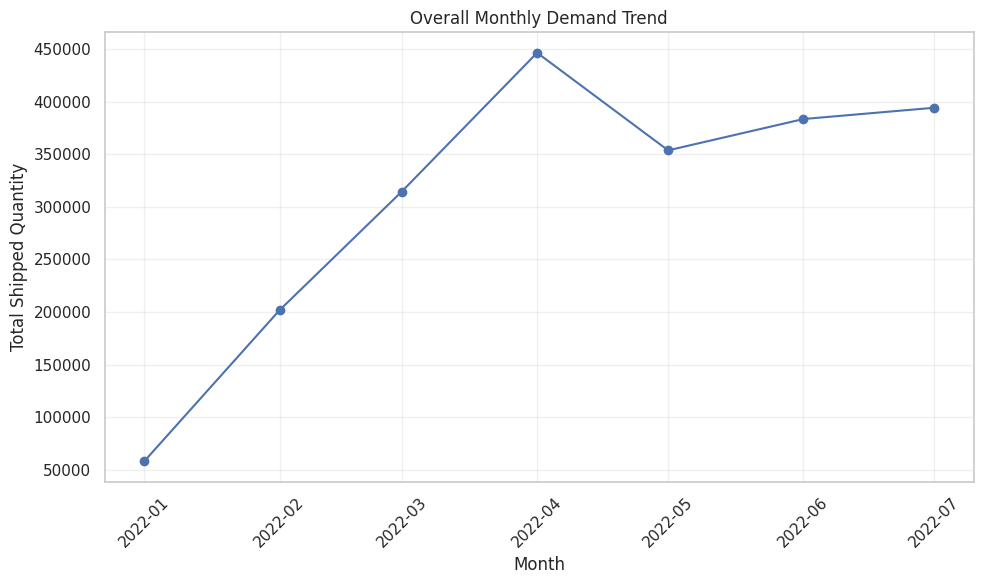

In [ ]:
# Create a line chart for monthly shipped quantity
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_demand['Month'],
    monthly_demand['Shipped Qty'],
    marker='o'
)

# Add chart title and axis labels
plt.title('Overall Monthly Demand Trend')
plt.xlabel('Month')
plt.ylabel('Total Shipped Quantity')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Add grid for easier interpretation
plt.grid(True, alpha=0.3)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

Overall demand shows a strong increasing pattern from January to April 2022, reaching its peak at 446,512 units in April. Demand then declined by approximately 20.8% in May before gradually recovering in June and July.

This indicates that demand is not consistently increasing and may be influenced by changes in demand patterns across categories, hubs, or weeks. Further analysis is required before selecting the appropriate forecasting method.

### b. Demand by Product Category

In [ ]:
# Calculate the total shipped quantity for each product category
category_demand = (
    df_demand
    .groupby('Category', as_index=False)['Shipped Qty']
    .sum()
    .sort_values('Shipped Qty', ascending=False)
    .reset_index(drop=True)
)

# Display the category demand summary
category_demand

,Category,Shipped Qty
0,H. Sayur & Buah,"703,770.00"
1,J. Susu & Olahan Susu,"311,949.00"
2,A. Bahan & Bumbu Masak,"249,131.00"
3,F. Paket Masak,"230,262.00"
4,I. Snack,"157,581.00"
5,B. Daging Beku,"145,590.00"
6,E. Minuman,"116,601.00"
7,D. Makanan Beku,"115,628.00"
8,G. Protein (Ayam & Telur),"85,245.00"
9,C. Kebutuhan Pokok,"36,279.00"


#### Visualize Demand Trend

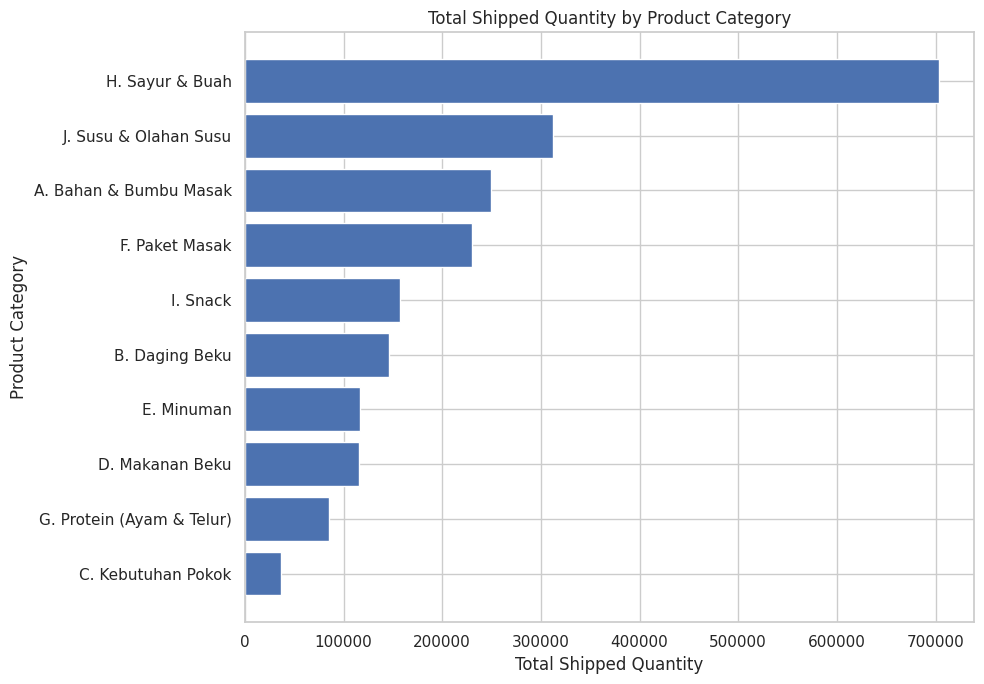

In [ ]:
# Create a horizontal bar chart for total demand by category
plt.figure(figsize=(10, 7))

plt.barh(
    category_demand['Category'],
    category_demand['Shipped Qty']
)

# Reverse the y-axis so the highest-demand category appears at the top
plt.gca().invert_yaxis()

# Add chart title and axis labels
plt.title('Total Shipped Quantity by Product Category')
plt.xlabel('Total Shipped Quantity')
plt.ylabel('Product Category')

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

Demand varies significantly across product categories. H. Sayur & Buah has the highest shipped quantity at 703,770 units, contributing approximately 32.7% of total demand during the observed period.

In contrast, C. Kebutuhan Pokok has the lowest demand at 36,279 units, representing only approximately 1.7% of total demand.

This indicates that demand is highly concentrated across certain product categories. Therefore, stock planning should consider category-level demand differences rather than applying a uniform restocking strategy across all categories.

### c. Monthly Demand by Product Category

In [ ]:
# Calculate the total shipped quantity by month and product category
monthly_category_demand = (
    df_demand
    .groupby(['Month', 'Category'], as_index=False)['Shipped Qty']
    .sum()
)

# Display the monthly category demand summary
monthly_category_demand.head(20)

,Month,Category,Shipped Qty
0,2022-01-01,A. Bahan & Bumbu Masak,"6,102.00"
1,2022-01-01,B. Daging Beku,"3,402.00"
2,2022-01-01,C. Kebutuhan Pokok,"3,851.00"
3,2022-01-01,D. Makanan Beku,"3,202.00"
4,2022-01-01,E. Minuman,"3,753.00"
5,2022-01-01,F. Paket Masak,"6,151.00"
6,2022-01-01,G. Protein (Ayam & Telur),"3,000.00"
7,2022-01-01,H. Sayur & Buah,"11,951.00"
8,2022-01-01,I. Snack,"3,400.00"
9,2022-01-01,J. Susu & Olahan Susu,"13,100.00"


#### Visualize Monthly Demand by Product Category

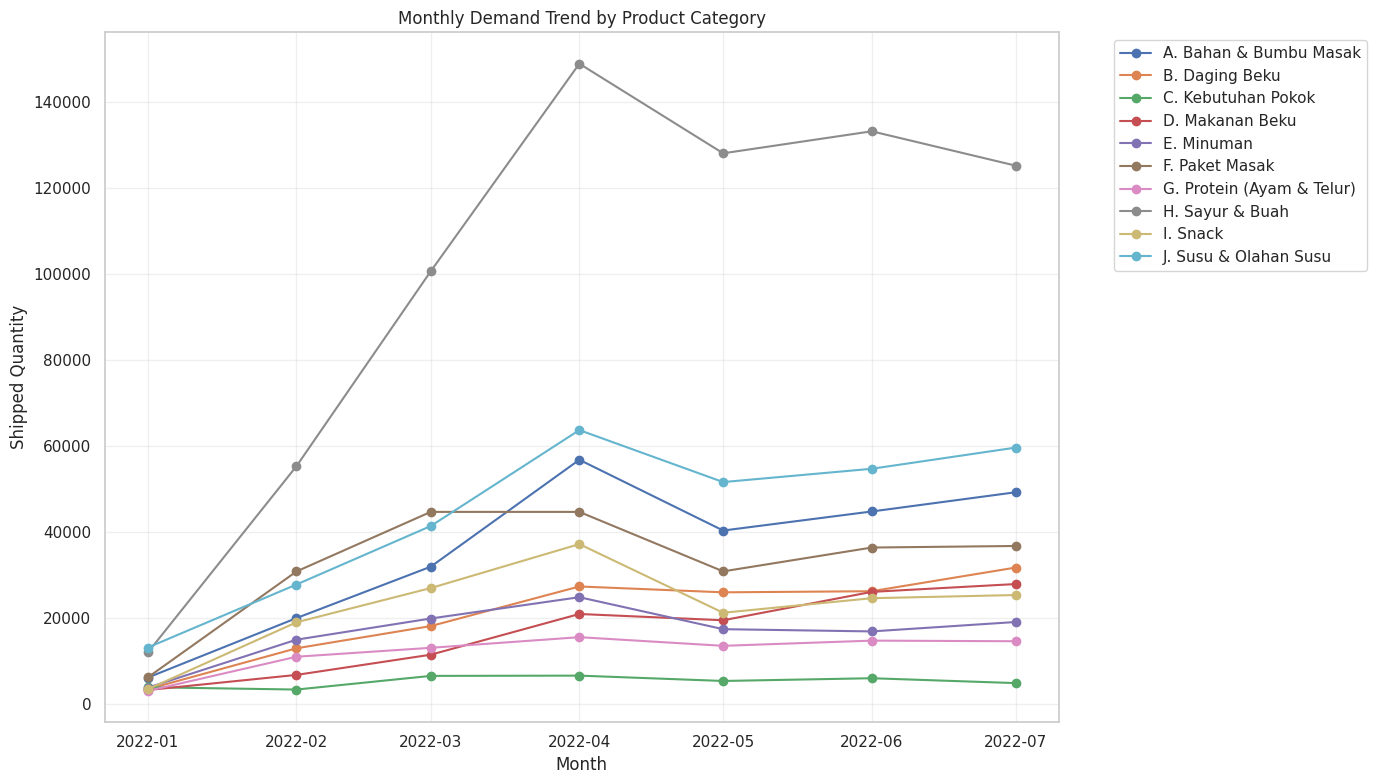

In [ ]:
# Create a line chart to compare monthly demand across categories
plt.figure(figsize=(14, 8))

for category in monthly_category_demand['Category'].unique():
    category_data = monthly_category_demand[
        monthly_category_demand['Category'] == category
    ]

    plt.plot(
        category_data['Month'],
        category_data['Shipped Qty'],
        marker='o',
        label=category
    )

# Add chart title and axis labels
plt.title('Monthly Demand Trend by Product Category')
plt.xlabel('Month')
plt.ylabel('Shipped Quantity')

# Add legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add grid for easier interpretation
plt.grid(True, alpha=0.3)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

Demand patterns vary across product categories, although most categories follow a similar temporal pattern. Demand generally increased from January to April, followed by a decline in May and a partial recovery in June and July.

H. Sayur & Buah consistently recorded the highest demand throughout the observed period, while C. Kebutuhan Pokok remained the lowest-demand category.

The common decline across categories after April suggests that the change in demand may be influenced by broader temporal factors rather than a single product category. However, the available seven-month period is not sufficient to confirm a seasonal pattern.

### d. Demand by Hub

In [ ]:
# Calculate the total shipped quantity for each hub
hub_demand = (
    df_demand
    .groupby('Hub', as_index=False)['Shipped Qty']
    .sum()
    .sort_values('Shipped Qty', ascending=False)
    .reset_index(drop=True)
)

# Display the hub demand summary
hub_demand

,Hub,Shipped Qty
0,E,"489,192.00"
1,C,"473,641.00"
2,D,"471,207.00"
3,B,"363,896.00"
4,A,"354,100.00"


#### Visualize Demand by Hub

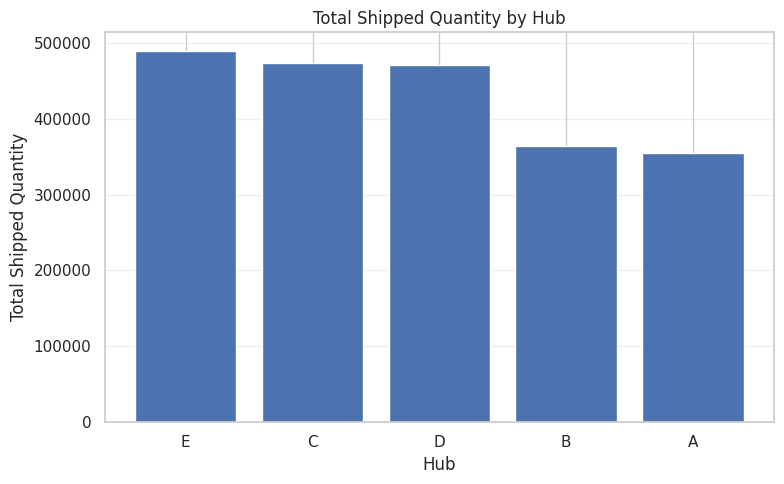

In [ ]:
# Create a bar chart for total demand by hub
plt.figure(figsize=(8, 5))

plt.bar(
    hub_demand['Hub'],
    hub_demand['Shipped Qty']
)

# Add chart title and axis labels
plt.title('Total Shipped Quantity by Hub')
plt.xlabel('Hub')
plt.ylabel('Total Shipped Quantity')

# Add grid for easier comparison
plt.grid(axis='y', alpha=0.3)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

Demand is distributed across all five hubs, with Hub E recording the highest total shipped quantity at 489,192 units and Hub A recording the lowest at 354,100 units.

Although demand varies across hubs, the difference is less pronounced than the variation observed across product categories. This suggests that product category may have a stronger influence on overall demand than hub location.

Further analysis of monthly demand by hub is required to determine whether the differences are consistent over time.

### e. Monthly Demand by Hub

In [ ]:
# Calculate the total shipped quantity by month and hub
monthly_hub_demand = (
    df_demand
    .groupby(['Month', 'Hub'], as_index=False)['Shipped Qty']
    .sum()
)

# Display the monthly hub demand summary
monthly_hub_demand.head(20)

,Month,Hub,Shipped Qty
0,2022-01-01,A,"10,051.00"
1,2022-01-01,B,"10,302.00"
2,2022-01-01,C,"12,602.00"
3,2022-01-01,D,"12,304.00"
4,2022-01-01,E,"12,653.00"
5,2022-02-01,A,"33,087.00"
6,2022-02-01,B,"34,604.00"
7,2022-02-01,C,"45,126.00"
8,2022-02-01,D,"43,716.00"
9,2022-02-01,E,"45,135.00"


#### Visualize Monthly Demand by Hub

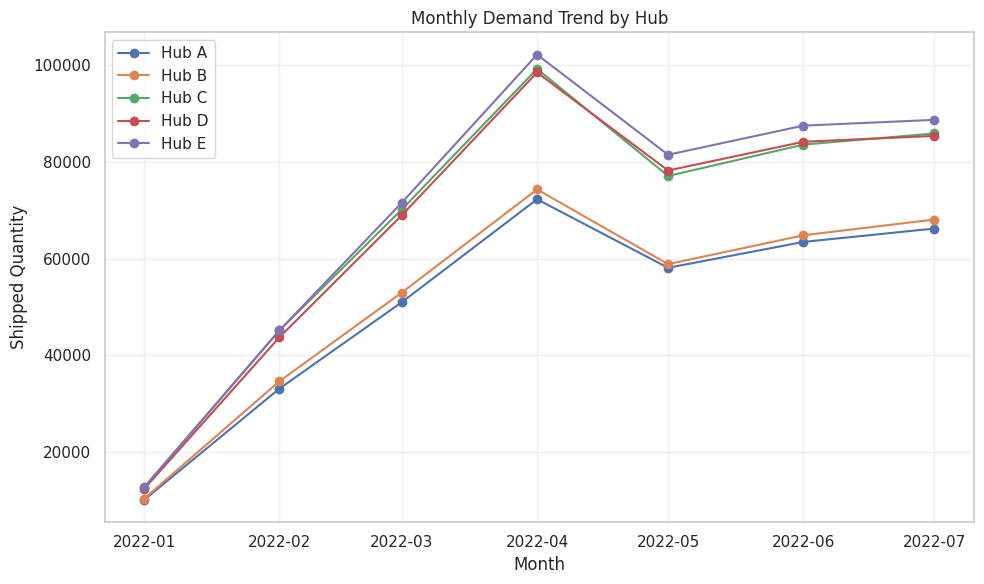

In [ ]:
# Create a line chart to compare monthly demand across hubs
plt.figure(figsize=(10, 6))

# Plot each hub's monthly demand
for hub in monthly_hub_demand['Hub'].unique():
    hub_data = monthly_hub_demand[
        monthly_hub_demand['Hub'] == hub
    ]

    plt.plot(
        hub_data['Month'],
        hub_data['Shipped Qty'],
        marker='o',
        label=f'Hub {hub}'
    )

# Add chart title and axis labels
plt.title('Monthly Demand Trend by Hub')
plt.xlabel('Month')
plt.ylabel('Shipped Quantity')

# Add legend
plt.legend()

# Add grid for easier interpretation
plt.grid(True, alpha=0.3)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

Demand patterns across hubs are highly similar over time, suggesting that the major demand fluctuations are driven by broader temporal factors rather than individual hub behavior.

## K. Forecasting Analysis

### Aggregate Weekly Demand

In [ ]:
# Calculate total shipped quantity for each month and week
weekly_demand = (
    df_demand
    .groupby(['Month', 'Week'], as_index=False)['Shipped Qty']
    .sum()
)

# Display the weekly demand summary
weekly_demand

,Month,Week,Shipped Qty
0,2022-01-01,W1,"8,691.00"
1,2022-01-01,W2,"11,580.00"
2,2022-01-01,W3,"14,481.00"
3,2022-01-01,W4,"23,160.00"
4,2022-02-01,W1,"30,254.00"
5,2022-02-01,W2,"40,330.00"
6,2022-02-01,W3,"50,423.00"
7,2022-02-01,W4,"80,661.00"
8,2022-03-01,W1,"47,177.00"
9,2022-03-01,W2,"62,896.00"


### Weekly Time Index

In [ ]:
# Create a sequential time index for each weekly observation
weekly_demand['Week_Index'] = range(1, len(weekly_demand) + 1)

# Display the weekly demand with the new time index
weekly_demand

,Month,Week,Shipped Qty,Week_Index
0,2022-01-01,W1,"8,691.00",1
1,2022-01-01,W2,"11,580.00",2
2,2022-01-01,W3,"14,481.00",3
3,2022-01-01,W4,"23,160.00",4
4,2022-02-01,W1,"30,254.00",5
5,2022-02-01,W2,"40,330.00",6
6,2022-02-01,W3,"50,423.00",7
7,2022-02-01,W4,"80,661.00",8
8,2022-03-01,W1,"47,177.00",9
9,2022-03-01,W2,"62,896.00",10


### Visualize Weekly Demand

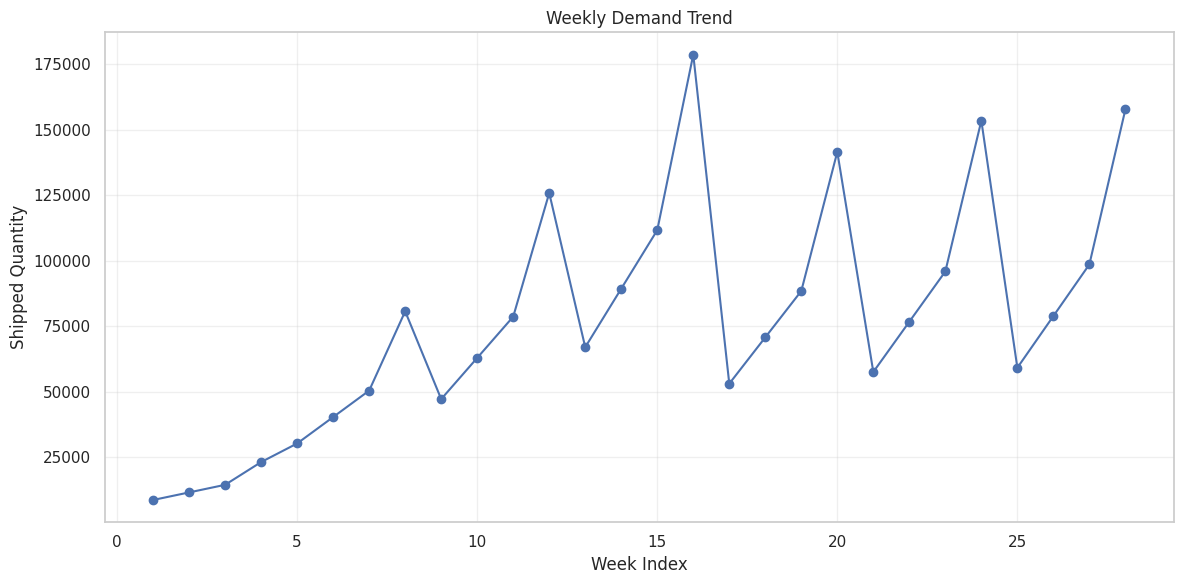

In [ ]:
# Create a line chart to visualize weekly demand over time
plt.figure(figsize=(12, 6))

plt.plot(
    weekly_demand['Week_Index'],
    weekly_demand['Shipped Qty'],
    marker='o'
)

# Add chart title and axis labels
plt.title('Weekly Demand Trend')
plt.xlabel('Week Index')
plt.ylabel('Shipped Quantity')

# Add grid for easier interpretation
plt.grid(True, alpha=0.3)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

### Analyze Weekly Seasonality

In [ ]:
# Calculate the average demand for each week of the month
weekly_seasonality = (
    weekly_demand
    .groupby('Week', as_index=False)['Shipped Qty']
    .mean()
)

# Display the average demand by week
weekly_seasonality

,Week,Shipped Qty
0,W1,"46,116.57"
1,W2,"61,486.00"
2,W3,"76,859.71"
3,W4,"122,971.43"


The weekly demand analysis shows two prominent patterns:

1. An overall upward trend in demand over time.
2. A recurring weekly pattern where demand consistently increases from W1 to W4 within each month.

Average demand increases from 46,116.57 units in W1 to 122,971.43 units in W4, indicating a strong recurring 4-week pattern.

These findings suggest that the forecasting approach should consider both trend and seasonal effects rather than relying solely on a trend-based model.

### Visualize the Seasonal Pattern

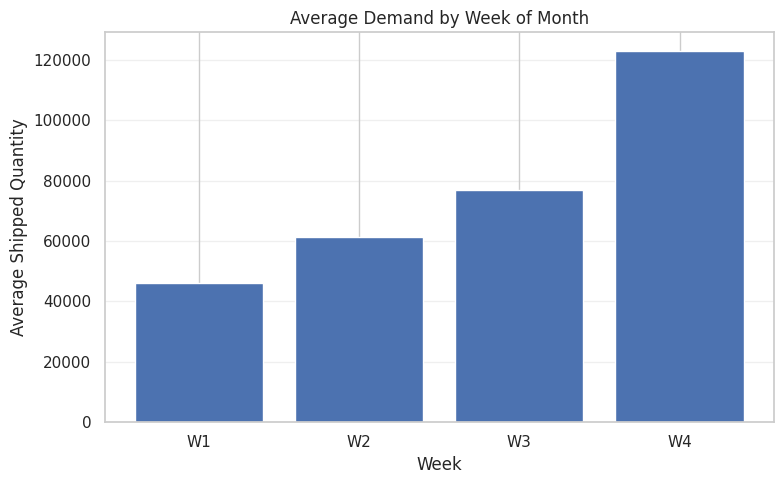

In [ ]:
# Create a bar chart for average demand by week
plt.figure(figsize=(8, 5))

plt.bar(
    weekly_seasonality['Week'],
    weekly_seasonality['Shipped Qty']
)

# Add chart title and axis labels
plt.title('Average Demand by Week of Month')
plt.xlabel('Week')
plt.ylabel('Average Shipped Quantity')

# Add grid for easier interpretation
plt.grid(axis='y', alpha=0.3)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

## L. Train & Validation Split

### Split Training and Validation Data

In [ ]:
# Use January to June 2022 as training data
train_data = weekly_demand[
    weekly_demand['Month'] < '2022-07-01'
].copy()

# Use July 2022 as validation data
validation_data = weekly_demand[
    weekly_demand['Month'] == '2022-07-01'
].copy()

# Display the number of observations in each dataset
print(f"Training observations: {len(train_data)}")
print(f"Validation observations: {len(validation_data)}")

Training observations: 24
Validation observations: 4


### Model 1: Moving Average Baseline

In [ ]:
# Combine training and validation data to simulate sequential forecasting
forecast_data = pd.concat(
    [train_data, validation_data]
).reset_index(drop=True)

# Create an empty list to store forecasts
moving_average_forecast = []

# Generate forecasts for the validation period
for i in range(len(train_data), len(forecast_data)):

    # Calculate the average demand from the previous 4 weeks
    previous_4_weeks = forecast_data.loc[i-4:i-1, 'Shipped Qty']
    forecast = previous_4_weeks.mean()

    # Store the forecast
    moving_average_forecast.append(forecast)

# Add the forecasts to the validation dataset
validation_ma = validation_data.copy()
validation_ma['Forecast'] = moving_average_forecast

# Display actual vs forecast demand
validation_ma[['Month', 'Week', 'Shipped Qty', 'Forecast']]

,Month,Week,Shipped Qty,Forecast
24,2022-07-01,W1,"59,135.00","95,875.00"
25,2022-07-01,W2,"78,850.00","96,277.25"
26,2022-07-01,W3,"98,561.00","96,815.00"
27,2022-07-01,W4,"157,696.00","97,486.25"


#### Evaluate Moving Average Baseline

In [ ]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Get actual and forecast values
actual = validation_ma['Shipped Qty']
forecast = validation_ma['Forecast']

# Calculate Mean Absolute Error (MAE)
mae_ma = mean_absolute_error(actual, forecast)

# Calculate Root Mean Squared Error (RMSE)
rmse_ma = np.sqrt(mean_squared_error(actual, forecast))

# Calculate Mean Absolute Percentage Error (MAPE)
mape_ma = np.mean(
    np.abs((actual - forecast) / actual)
) * 100

# Display evaluation metrics
print(f"MAE  : {mae_ma:,.2f}")
print(f"RMSE : {rmse_ma:,.2f}")
print(f"MAPE : {mape_ma:.2f}%")

MAE  : 29,030.75
RMSE : 36,337.99
MAPE : 31.05%


### Model 2: Linear Regression

In [ ]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Define training features and target
X_train = train_data[['Week_Index']]
y_train = train_data['Shipped Qty']

# Define validation features and target
X_validation = validation_data[['Week_Index']]
y_validation = validation_data['Shipped Qty']

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

# Generate predictions for the validation period
linear_forecast = linear_model.predict(X_validation)

# Add predictions to the validation dataset
validation_lr = validation_data.copy()
validation_lr['Forecast'] = linear_forecast

# Display actual vs forecast demand
validation_lr[['Month', 'Week', 'Shipped Qty', 'Forecast']]

,Month,Week,Shipped Qty,Forecast
24,2022-07-01,W1,"59,135.00","129,058.75"
25,2022-07-01,W2,"78,850.00","133,524.14"
26,2022-07-01,W3,"98,561.00","137,989.53"
27,2022-07-01,W4,"157,696.00","142,454.91"


#### Evaluate Linear *Regression*

In [ ]:
# Get actual and forecast values
actual_lr = validation_lr['Shipped Qty']
forecast_lr = validation_lr['Forecast']

# Calculate Mean Absolute Error (MAE)
mae_lr = mean_absolute_error(actual_lr, forecast_lr)

# Calculate Root Mean Squared Error (RMSE)
rmse_lr = np.sqrt(mean_squared_error(actual_lr, forecast_lr))

# Calculate Mean Absolute Percentage Error (MAPE)
mape_lr = np.mean(
    np.abs((actual_lr - forecast_lr) / actual_lr)
) * 100

# Display evaluation metrics
print(f"MAE  : {mae_lr:,.2f}")
print(f"RMSE : {rmse_lr:,.2f}")
print(f"MAPE : {mape_lr:.2f}%")

MAE  : 44,816.88
RMSE : 49,156.62
MAPE : 59.31%


### Prepare Features for Seasonal Model

In [ ]:
# Create one-hot encoded variables for the week-of-month
week_dummies = pd.get_dummies(
    weekly_demand['Week'],
    prefix='Week',
    drop_first=True
)

# Combine the time index with the seasonal variables
seasonal_data = pd.concat(
    [
        weekly_demand[['Month', 'Week', 'Shipped Qty', 'Week_Index']],
        week_dummies
    ],
    axis=1
)

# Display the prepared dataset
seasonal_data.head()

,Month,Week,Shipped Qty,Week_Index,Week_W2,Week_W3,Week_W4
0,2022-01-01,W1,"8,691.00",1,False,False,False
1,2022-01-01,W2,"11,580.00",2,True,False,False
2,2022-01-01,W3,"14,481.00",3,False,True,False
3,2022-01-01,W4,"23,160.00",4,False,False,True
4,2022-02-01,W1,"30,254.00",5,False,False,False


### Model 3: Seasonal Linear Regression

In [ ]:
# Define the features used by the seasonal regression model
features = ['Week_Index', 'Week_W2', 'Week_W3', 'Week_W4']

# Split the data into training and validation sets
seasonal_train = seasonal_data[
    seasonal_data['Month'] < '2022-07-01'
].copy()

seasonal_validation = seasonal_data[
    seasonal_data['Month'] == '2022-07-01'
].copy()

# Define training features and target
X_train_seasonal = seasonal_train[features]
y_train_seasonal = seasonal_train['Shipped Qty']

# Define validation features and target
X_validation_seasonal = seasonal_validation[features]
y_validation_seasonal = seasonal_validation['Shipped Qty']

# Create the Linear Regression model
seasonal_model = LinearRegression()

# Train the model
seasonal_model.fit(
    X_train_seasonal,
    y_train_seasonal
)

# Generate forecasts for July 2022
seasonal_forecast = seasonal_model.predict(
    X_validation_seasonal
)

# Add forecasts to the validation dataset
validation_seasonal = seasonal_validation.copy()
validation_seasonal['Forecast'] = seasonal_forecast

# Display actual vs forecast demand
validation_seasonal[
    ['Month', 'Week', 'Shipped Qty', 'Forecast']
]

,Month,Week,Shipped Qty,Forecast
24,2022-07-01,W1,"59,135.00","99,348.18"
25,2022-07-01,W2,"78,850.00","113,993.35"
26,2022-07-01,W3,"98,561.00","128,644.18"
27,2022-07-01,W4,"157,696.00","172,585.35"


#### Evaluate Seasonal Regression Model

In [ ]:
# Get actual and forecast values
actual_seasonal = validation_seasonal['Shipped Qty']
forecast_seasonal = validation_seasonal['Forecast']

# Calculate Mean Absolute Error (MAE)
mae_seasonal = mean_absolute_error(
    actual_seasonal,
    forecast_seasonal
)

# Calculate Root Mean Squared Error (RMSE)
rmse_seasonal = np.sqrt(
    mean_squared_error(
        actual_seasonal,
        forecast_seasonal
    )
)

# Calculate Mean Absolute Percentage Error (MAPE)
mape_seasonal = np.mean(
    np.abs(
        (actual_seasonal - forecast_seasonal)
        / actual_seasonal
    )
) * 100

# Display evaluation metrics
print(f"MAE  : {mae_seasonal:,.2f}")
print(f"RMSE : {rmse_seasonal:,.2f}")
print(f"MAPE : {mape_seasonal:.2f}%")

MAE  : 30,082.27
RMSE : 31,539.05
MAPE : 38.13%


### Model Comparison & Selection

In [ ]:
# Create a comparison table for all forecasting models
model_comparison = pd.DataFrame({
    'Model': [
        '4-Week Moving Average',
        'Linear Regression',
        'Seasonal Linear Regression'
    ],
    'MAE': [
        mae_ma,
        mae_lr,
        mae_seasonal
    ],
    'RMSE': [
        rmse_ma,
        rmse_lr,
        rmse_seasonal
    ],
    'MAPE (%)': [
        mape_ma,
        mape_lr,
        mape_seasonal
    ]
})

# Sort models based on MAPE from lowest to highest
model_comparison = model_comparison.sort_values(
    'MAPE (%)'
).reset_index(drop=True)

# Display the model comparison
model_comparison

,Model,MAE,RMSE,MAPE (%)
0,4-Week Moving Average,"29,030.75","36,337.99",31.05
1,Seasonal Linear Regression,"30,082.27","31,539.05",38.13
2,Linear Regression,"44,816.88","49,156.62",59.31


In [ ]:
# Identify the best-performing model based on MAPE
best_model = model_comparison.iloc[0]

print("Best forecasting model based on MAPE:")
print(f"Model : {best_model['Model']}")
print(f"MAPE  : {best_model['MAPE (%)']:.2f}%")

Best forecasting model based on MAPE:
Model : 4-Week Moving Average
MAPE  : 31.05%


Seasonal Linear Regression produced the lowest RMSE, indicating better performance in reducing large forecasting errors. However, the 4-Week Moving Average achieved the lowest MAE and MAPE, making it the preferred model for the final forecast.

## M. Final Forecast August 2022

### Prepare Final FOrecastt Data

In [ ]:
# Display the latest 4 weeks of actual demand
latest_4_weeks = weekly_demand.tail(4)

latest_4_weeks

,Month,Week,Shipped Qty,Week_Index
24,2022-07-01,W1,"59,135.00",25
25,2022-07-01,W2,"78,850.00",26
26,2022-07-01,W3,"98,561.00",27
27,2022-07-01,W4,"157,696.00",28


### Forecast August 2022

In [ ]:
# Create a list containing the latest 4 weeks of actual demand
forecast_history = latest_4_weeks['Shipped Qty'].tolist()

# Create an empty list to store August forecasts
august_forecasts = []

# Generate forecasts for August W1 to W4
for week in range(1, 5):

    # Calculate the average of the latest 4 demand observations
    forecast = np.mean(forecast_history[-4:])

    # Store the forecast
    august_forecasts.append(forecast)

    # Add the forecast to the history for the next week's calculation
    forecast_history.append(forecast)

# Create the August forecast table
august_forecast = pd.DataFrame({
    'Week': ['W1', 'W2', 'W3', 'W4'],
    'Forecasted Demand': august_forecasts
})

# Display the August forecast
august_forecast

,Week,Forecasted Demand
0,W1,"98,560.50"
1,W2,"108,416.88"
2,W3,"115,808.59"
3,W4,"120,120.49"


## N. Category-Level Forecast

### Monthly Demand by Category

In [ ]:
monthly_category_demand = (
    df_demand
    .groupby(['Month', 'Category'], as_index=False)['Shipped Qty']
    .sum()
)

# Sort by month and category
monthly_category_demand = monthly_category_demand.sort_values(
    ['Month', 'Category']
).reset_index(drop=True)

# Display the first 20 rows
monthly_category_demand.head(20)

,Month,Category,Shipped Qty
0,2022-01-01,A. Bahan & Bumbu Masak,"6,102.00"
1,2022-01-01,B. Daging Beku,"3,402.00"
2,2022-01-01,C. Kebutuhan Pokok,"3,851.00"
3,2022-01-01,D. Makanan Beku,"3,202.00"
4,2022-01-01,E. Minuman,"3,753.00"
5,2022-01-01,F. Paket Masak,"6,151.00"
6,2022-01-01,G. Protein (Ayam & Telur),"3,000.00"
7,2022-01-01,H. Sayur & Buah,"11,951.00"
8,2022-01-01,I. Snack,"3,400.00"
9,2022-01-01,J. Susu & Olahan Susu,"13,100.00"


### Category Demand Share

In [ ]:
# Calculate total historical demand for each category
category_total = (
    monthly_category_demand
    .groupby('Category', as_index=False)['Shipped Qty']
    .sum()
)

# Calculate total demand across all categories
total_demand = category_total['Shipped Qty'].sum()

# Calculate each category's share of total demand
category_total['Demand Share (%)'] = (
    category_total['Shipped Qty'] / total_demand * 100
)

# Sort from highest to lowest demand share
category_total = category_total.sort_values(
    'Demand Share (%)',
    ascending=False
).reset_index(drop=True)

category_total

,Category,Shipped Qty,Demand Share (%)
0,H. Sayur & Buah,"703,770.00",32.70
1,J. Susu & Olahan Susu,"311,949.00",14.50
2,A. Bahan & Bumbu Masak,"249,131.00",11.58
3,F. Paket Masak,"230,262.00",10.70
4,I. Snack,"157,581.00",7.32
5,B. Daging Beku,"145,590.00",6.77
6,E. Minuman,"116,601.00",5.42
7,D. Makanan Beku,"115,628.00",5.37
8,G. Protein (Ayam & Telur),"85,245.00",3.96
9,C. Kebutuhan Pokok,"36,279.00",1.69


### Check Monthly Category Share

In [ ]:
# Calculate total demand for each month
monthly_total = (
    monthly_category_demand
    .groupby('Month')['Shipped Qty']
    .transform('sum')
)

# Calculate each category's share within its month
monthly_category_share = monthly_category_demand.copy()

monthly_category_share['Demand Share (%)'] = (
    monthly_category_share['Shipped Qty'] / monthly_total * 100
)

# Display the monthly category share
monthly_category_share.head(20)

,Month,Category,Shipped Qty,Demand Share (%)
0,2022-01-01,A. Bahan & Bumbu Masak,"6,102.00",10.54
1,2022-01-01,B. Daging Beku,"3,402.00",5.87
2,2022-01-01,C. Kebutuhan Pokok,"3,851.00",6.65
3,2022-01-01,D. Makanan Beku,"3,202.00",5.53
4,2022-01-01,E. Minuman,"3,753.00",6.48
5,2022-01-01,F. Paket Masak,"6,151.00",10.62
6,2022-01-01,G. Protein (Ayam & Telur),"3,000.00",5.18
7,2022-01-01,H. Sayur & Buah,"11,951.00",20.64
8,2022-01-01,I. Snack,"3,400.00",5.87
9,2022-01-01,J. Susu & Olahan Susu,"13,100.00",22.62


### Category Share Stability

In [ ]:
category_share_stability = (
    monthly_category_share
    .groupby('Category')['Demand Share (%)']
    .agg(['mean', 'std'])
    .reset_index()
)

# Rename columns
category_share_stability.columns = [
    'Category',
    'Average Share (%)',
    'Share Std Dev (%)'
]

# Sort by average share
category_share_stability = category_share_stability.sort_values(
    'Average Share (%)',
    ascending=False
).reset_index(drop=True)

category_share_stability

,Category,Average Share (%),Share Std Dev (%)
0,H. Sayur & Buah,30.89,5.31
1,J. Susu & Olahan Susu,15.40,3.24
2,A. Bahan & Bumbu Masak,11.27,1.12
3,F. Paket Masak,11.09,2.58
4,I. Snack,7.28,1.44
5,B. Daging Beku,6.62,0.84
6,E. Minuman,5.70,1.08
7,D. Makanan Beku,5.22,1.44
8,G. Protein (Ayam & Telur),4.22,0.77
9,C. Kebutuhan Pokok,2.30,1.93


In [ ]:
# Check whether the average category shares add up to 100%
total_average_share = category_share_stability['Average Share (%)'].sum()

print(f"Total average category share: {total_average_share:.2f}%")

Total average category share: 100.00%


### Category Share Stability using CV

In [ ]:

category_share_stability['CV (%)'] = (
    category_share_stability['Share Std Dev (%)']
    / category_share_stability['Average Share (%)']
) * 100

# Sort by CV from lowest to highest
category_share_stability = category_share_stability.sort_values(
    'CV (%)',
    ascending=True
).reset_index(drop=True)

category_share_stability

,Category,Average Share (%),Share Std Dev (%),CV (%)
0,A. Bahan & Bumbu Masak,11.27,1.12,9.91
1,B. Daging Beku,6.62,0.84,12.62
2,H. Sayur & Buah,30.89,5.31,17.17
3,G. Protein (Ayam & Telur),4.22,0.77,18.19
4,E. Minuman,5.70,1.08,18.94
5,I. Snack,7.28,1.44,19.75
6,J. Susu & Olahan Susu,15.40,3.24,21.06
7,F. Paket Masak,11.09,2.58,23.28
8,D. Makanan Beku,5.22,1.44,27.59
9,C. Kebutuhan Pokok,2.30,1.93,84.15


### Allocate August Forecast by Category

In [ ]:
# Get category average share
category_share = category_share_stability[
    ['Category', 'Average Share (%)']
].copy()

# Convert percentage into decimal
category_share['Share'] = (
    category_share['Average Share (%)'] / 100
)

# Convert August forecast into a dictionary
august_forecast_dict = dict(
    zip(
        august_forecast['Week'],
        august_forecast['Forecasted Demand']
    )
)

# Calculate category-level forecast for each week
for week, total_forecast in august_forecast_dict.items():
    category_share[f'August {week}'] = (
        category_share['Share'] * total_forecast
    )

# Display the category-level forecast
category_forecast = category_share[
    ['Category', 'Average Share (%)',
     'August W1', 'August W2', 'August W3', 'August W4']
].copy()

category_forecast

,Category,Average Share (%),August W1,August W2,August W3,August W4
0,A. Bahan & Bumbu Masak,11.27,"11,104.97","12,215.50","13,048.34","13,534.17"
1,B. Daging Beku,6.62,"6,528.01","7,180.83","7,670.41","7,956.00"
2,H. Sayur & Buah,30.89,"30,447.14","33,491.95","35,775.39","37,107.41"
3,G. Protein (Ayam & Telur),4.22,"4,163.35","4,579.70","4,891.93","5,074.07"
4,E. Minuman,5.70,"5,615.77","6,177.36","6,598.53","6,844.21"
5,I. Snack,7.28,"7,180.01","7,898.04","8,436.51","8,750.63"
6,J. Susu & Olahan Susu,15.40,"15,179.56","16,697.56","17,835.98","18,500.07"
7,F. Paket Masak,11.09,"10,930.62","12,023.72","12,843.48","13,321.68"
8,D. Makanan Beku,5.22,"5,144.66","5,659.15","6,044.98","6,270.05"
9,C. Kebutuhan Pokok,2.30,"2,266.42","2,493.07","2,663.04","2,762.19"


### Validate Category Fprecast Allocation

In [ ]:
# Calculate total category forecast for each week
category_totals = category_forecast[
    ['August W1', 'August W2', 'August W3', 'August W4']
].sum()

# Display category totals
print("Total category forecast:")
print(category_totals)

print("\nOriginal overall forecast:")
print(august_forecast)

Total category forecast:
August W1    98,560.50
August W2   108,416.87
August W3   115,808.59
August W4   120,120.49
dtype: float64

Original overall forecast:
  Week  Forecasted Demand
0   W1          98,560.50
1   W2         108,416.88
2   W3         115,808.59
3   W4         120,120.49


### Create Demand Score & Volatility Score

In [ ]:
priority_data = category_share_stability.copy()

# Demand Score based on average demand share
priority_data['Demand Score'] = np.select(
    [
        priority_data['Average Share (%)'] >= 15,
        priority_data['Average Share (%)'] >= 5
    ],
    [
        3,
        2
    ],
    default=1
)

# Volatility Score based on CV
priority_data['Volatility Score'] = np.select(
    [
        priority_data['CV (%)'] >= 30,
        priority_data['CV (%)'] >= 20
    ],
    [
        3,
        2
    ],
    default=1
)

# Calculate total priority score
priority_data['Priority Score'] = (
    priority_data['Demand Score']
    + priority_data['Volatility Score']
)

priority_data[
    [
        'Category',
        'Average Share (%)',
        'CV (%)',
        'Demand Score',
        'Volatility Score',
        'Priority Score'
    ]
]

,Category,Average Share (%),CV (%),Demand Score,Volatility Score,Priority Score
0,A. Bahan & Bumbu Masak,11.27,9.91,2,1,3
1,B. Daging Beku,6.62,12.62,2,1,3
2,H. Sayur & Buah,30.89,17.17,3,1,4
3,G. Protein (Ayam & Telur),4.22,18.19,1,1,2
4,E. Minuman,5.70,18.94,2,1,3
5,I. Snack,7.28,19.75,2,1,3
6,J. Susu & Olahan Susu,15.40,21.06,3,2,5
7,F. Paket Masak,11.09,23.28,2,2,4
8,D. Makanan Beku,5.22,27.59,2,2,4
9,C. Kebutuhan Pokok,2.30,84.15,1,3,4


### Assign Priority Level

In [ ]:
priority_data['Priority Level'] = np.select(
    [
        priority_data['Priority Score'] >= 5,
        priority_data['Priority Score'] == 4,
        priority_data['Priority Score'] == 3
    ],
    [
        'Critical',
        'High',
        'Medium'
    ],
    default='Low'
)

# Display the final priority assessment
priority_data[
    [
        'Category',
        'Average Share (%)',
        'CV (%)',
        'Demand Score',
        'Volatility Score',
        'Priority Score',
        'Priority Level'
    ]
]

,Category,Average Share (%),CV (%),Demand Score,Volatility Score,Priority Score,Priority Level
0,A. Bahan & Bumbu Masak,11.27,9.91,2,1,3,Medium
1,B. Daging Beku,6.62,12.62,2,1,3,Medium
2,H. Sayur & Buah,30.89,17.17,3,1,4,High
3,G. Protein (Ayam & Telur),4.22,18.19,1,1,2,Low
4,E. Minuman,5.70,18.94,2,1,3,Medium
5,I. Snack,7.28,19.75,2,1,3,Medium
6,J. Susu & Olahan Susu,15.40,21.06,3,2,5,Critical
7,F. Paket Masak,11.09,23.28,2,2,4,High
8,D. Makanan Beku,5.22,27.59,2,2,4,High
9,C. Kebutuhan Pokok,2.30,84.15,1,3,4,High


### Combine Forecast + Inventory Priority

In [ ]:
# Get priority information
priority_summary = priority_data[
    ['Category', 'CV (%)', 'Demand Score',
     'Volatility Score', 'Priority Score', 'Priority Level']
].copy()

# Merge forecast with priority
final_stock_planning = category_forecast.merge(
    priority_summary,
    on='Category',
    how='left'
)

# Sort by priority and demand
priority_order = {
    'Critical': 1,
    'High': 2,
    'Medium': 3,
    'Low': 4
}

final_stock_planning['Priority Rank'] = (
    final_stock_planning['Priority Level']
    .map(priority_order)
)

final_stock_planning = final_stock_planning.sort_values(
    ['Priority Rank', 'August W1'],
    ascending=[True, False]
).reset_index(drop=True)

# Display final table
final_stock_planning[
    [
        'Category',
        'Average Share (%)',
        'August W1',
        'August W2',
        'August W3',
        'August W4',
        'CV (%)',
        'Priority Level'
    ]
]

,Category,Average Share (%),August W1,August W2,August W3,August W4,CV (%),Priority Level
0,J. Susu & Olahan Susu,15.40,"15,179.56","16,697.56","17,835.98","18,500.07",21.06,Critical
1,H. Sayur & Buah,30.89,"30,447.14","33,491.95","35,775.39","37,107.41",17.17,High
2,F. Paket Masak,11.09,"10,930.62","12,023.72","12,843.48","13,321.68",23.28,High
3,D. Makanan Beku,5.22,"5,144.66","5,659.15","6,044.98","6,270.05",27.59,High
4,C. Kebutuhan Pokok,2.30,"2,266.42","2,493.07","2,663.04","2,762.19",84.15,High
5,A. Bahan & Bumbu Masak,11.27,"11,104.97","12,215.50","13,048.34","13,534.17",9.91,Medium
6,I. Snack,7.28,"7,180.01","7,898.04","8,436.51","8,750.63",19.75,Medium
7,B. Daging Beku,6.62,"6,528.01","7,180.83","7,670.41","7,956.00",12.62,Medium
8,E. Minuman,5.70,"5,615.77","6,177.36","6,598.53","6,844.21",18.94,Medium
9,G. Protein (Ayam & Telur),4.22,"4,163.35","4,579.70","4,891.93","5,074.07",18.19,Low


### Total August Forecast per Category

In [ ]:
final_stock_planning['August Total Forecast'] = (
    final_stock_planning[
        ['August W1', 'August W2', 'August W3', 'August W4']
    ].sum(axis=1)
)

# Sort by total forecast
august_category_total = final_stock_planning.sort_values(
    'August Total Forecast',
    ascending=False
)

august_category_total[
    ['Category', 'August Total Forecast', 'Priority Level']
]

,Category,August Total Forecast,Priority Level
1,H. Sayur & Buah,"136,821.89",High
0,J. Susu & Olahan Susu,"68,213.17",Critical
5,A. Bahan & Bumbu Masak,"49,902.98",Medium
2,F. Paket Masak,"49,119.50",High
6,I. Snack,"32,265.19",Medium
7,B. Daging Beku,"29,335.24",Medium
8,E. Minuman,"25,235.87",Medium
3,D. Makanan Beku,"23,118.84",High
9,G. Protein (Ayam & Telur),"18,709.05",Low
4,C. Kebutuhan Pokok,"10,184.72",High


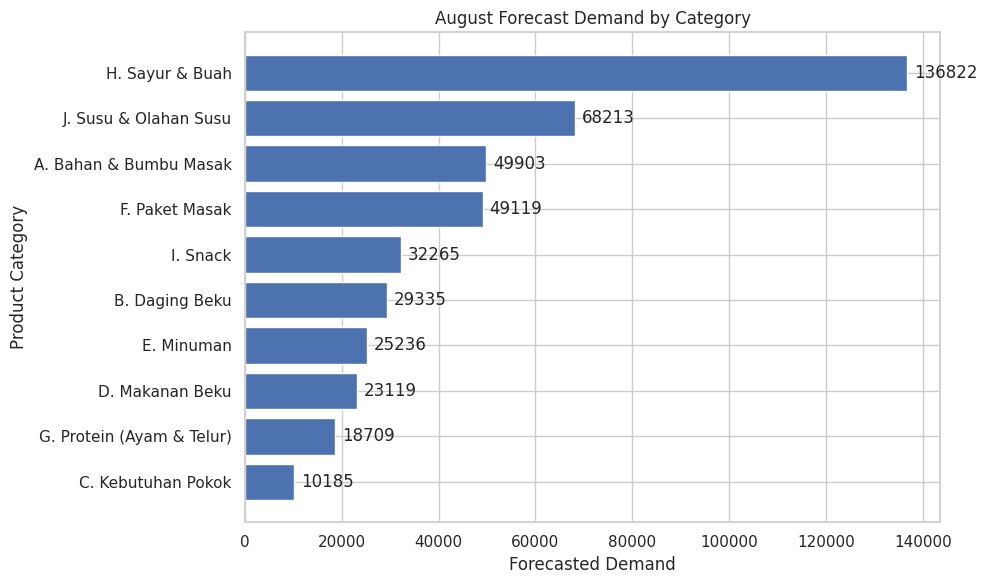

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    august_category_total['Category'],
    august_category_total['August Total Forecast']
)

ax.set_xlabel('Forecasted Demand')
ax.set_ylabel('Product Category')
ax.set_title('August Forecast Demand by Category')

ax.invert_yaxis()

# Add exact forecast values
ax.bar_label(
    bars,
    fmt='%.0f',
    padding=5
)

plt.tight_layout()
plt.show()

### Calculate Hub Demand Share

In [ ]:
hub_total = (
    df_demand
    .groupby('Hub', as_index=False)['Shipped Qty']
    .sum()
)

# Calculate total demand
total_hub_demand = hub_total['Shipped Qty'].sum()

# Calculate each hub's demand share
hub_total['Demand Share (%)'] = (
    hub_total['Shipped Qty']
    / total_hub_demand
    * 100
)

# Sort by demand share
hub_total = hub_total.sort_values(
    'Demand Share (%)',
    ascending=False
).reset_index(drop=True)

hub_total

,Hub,Shipped Qty,Demand Share (%)
0,E,"489,192.00",22.73
1,C,"473,641.00",22.01
2,D,"471,207.00",21.90
3,B,"363,896.00",16.91
4,A,"354,100.00",16.45


### Monthly Hub Share

In [ ]:
monthly_hub_demand = (
    df_demand
    .groupby(['Month', 'Hub'], as_index=False)['Shipped Qty']
    .sum()
)

# Calculate total demand for each month
monthly_total_hub = (
    monthly_hub_demand
    .groupby('Month')['Shipped Qty']
    .transform('sum')
)

# Calculate each hub's share within each month
monthly_hub_demand['Demand Share (%)'] = (
    monthly_hub_demand['Shipped Qty']
    / monthly_total_hub
    * 100
)

monthly_hub_demand = monthly_hub_demand.sort_values(
    ['Month', 'Hub']
).reset_index(drop=True)

monthly_hub_demand.head(20)

,Month,Hub,Shipped Qty,Demand Share (%)
0,2022-01-01,A,"10,051.00",17.36
1,2022-01-01,B,"10,302.00",17.79
2,2022-01-01,C,"12,602.00",21.76
3,2022-01-01,D,"12,304.00",21.25
4,2022-01-01,E,"12,653.00",21.85
5,2022-02-01,A,"33,087.00",16.41
6,2022-02-01,B,"34,604.00",17.16
7,2022-02-01,C,"45,126.00",22.38
8,2022-02-01,D,"43,716.00",21.68
9,2022-02-01,E,"45,135.00",22.38


### Hub Share Stability

In [ ]:
hub_share_stability = (
    monthly_hub_demand
    .groupby('Hub')['Demand Share (%)']
    .agg(['mean', 'std'])
    .reset_index()
)

# Rename columns
hub_share_stability.columns = [
    'Hub',
    'Average Share (%)',
    'Share Std Dev (%)'
]

# Calculate Coefficient of Variation
hub_share_stability['CV (%)'] = (
    hub_share_stability['Share Std Dev (%)']
    / hub_share_stability['Average Share (%)']
) * 100

# Sort by average share
hub_share_stability = hub_share_stability.sort_values(
    'Average Share (%)',
    ascending=False
).reset_index(drop=True)

hub_share_stability

,Hub,Average Share (%),Share Std Dev (%),CV (%)
0,E,22.60,0.40,1.77
1,C,22.00,0.28,1.28
2,D,21.80,0.30,1.38
3,B,17.03,0.41,2.41
4,A,16.56,0.41,2.47


### Forecast August by Hub

In [ ]:
# Get average hub share
hub_shares = hub_share_stability[
    ['Hub', 'Average Share (%)']
].copy()

# Forecast August total demand from our best model
august_overall_forecast = {
    'W1': 98560.50,
    'W2': 108416.88,
    'W3': 115808.59,
    'W4': 120120.49
}

# Create forecast table
august_hub_forecast = hub_shares.copy()

for week, total_forecast in august_overall_forecast.items():
    august_hub_forecast[f'August {week}'] = (
        august_hub_forecast['Average Share (%)']
        / 100
        * total_forecast
    )

# Display result
august_hub_forecast

,Hub,Average Share (%),August W1,August W2,August W3,August W4
0,E,22.60,"22,276.38","24,504.09","26,174.75","27,149.31"
1,C,22.00,"21,687.80","23,856.65","25,483.16","26,431.98"
2,D,21.80,"21,488.46","23,637.38","25,248.95","26,189.04"
3,B,17.03,"16,787.76","18,466.59","19,725.62","20,460.06"
4,A,16.56,"16,320.10","17,952.16","19,176.12","19,890.10"


### Hub × Category Analysis

In [ ]:
hub_category_demand = (
    df_demand
    .groupby(['Hub', 'Category'], as_index=False)['Shipped Qty']
    .sum()
)

# Calculate category share within each hub
hub_totals = (
    hub_category_demand
    .groupby('Hub')['Shipped Qty']
    .transform('sum')
)

hub_category_demand['Category Share in Hub (%)'] = (
    hub_category_demand['Shipped Qty']
    / hub_totals
    * 100
)

# Sort by Hub and demand
hub_category_demand = hub_category_demand.sort_values(
    ['Hub', 'Shipped Qty'],
    ascending=[True, False]
).reset_index(drop=True)

hub_category_demand.head(20)

,Hub,Category,Shipped Qty,Category Share in Hub (%)
0,A,H. Sayur & Buah,"88,340.00",24.95
1,A,J. Susu & Olahan Susu,"42,862.00",12.10
2,A,B. Daging Beku,"42,820.00",12.09
3,A,A. Bahan & Bumbu Masak,"40,841.00",11.53
4,A,F. Paket Masak,"37,443.00",10.57
5,A,D. Makanan Beku,"32,519.00",9.18
6,A,E. Minuman,"23,321.00",6.59
7,A,I. Snack,"18,539.00",5.24
8,A,G. Protein (Ayam & Telur),"17,049.00",4.81
9,A,C. Kebutuhan Pokok,"10,366.00",2.93


### Hub × Category Share Stability

In [ ]:
# Calculate monthly demand for each Hub × Category
monthly_hub_category = (
    df_demand
    .groupby(['Month', 'Hub', 'Category'], as_index=False)['Shipped Qty']
    .sum()
)

# Calculate total demand within each Hub for each month
monthly_hub_total = (
    monthly_hub_category
    .groupby(['Month', 'Hub'])['Shipped Qty']
    .transform('sum')
)

# Calculate category share within each Hub each month
monthly_hub_category['Category Share (%)'] = (
    monthly_hub_category['Shipped Qty']
    / monthly_hub_total
    * 100
)

# Calculate average share and standard deviation
hub_category_stability = (
    monthly_hub_category
    .groupby(['Hub', 'Category'])['Category Share (%)']
    .agg(['mean', 'std'])
    .reset_index()
)

# Rename columns
hub_category_stability.columns = [
    'Hub',
    'Category',
    'Average Share (%)',
    'Share Std Dev (%)'
]

# Calculate CV
hub_category_stability['CV (%)'] = (
    hub_category_stability['Share Std Dev (%)']
    / hub_category_stability['Average Share (%)']
) * 100

# Sort for easier reading
hub_category_stability = hub_category_stability.sort_values(
    ['Hub', 'Average Share (%)'],
    ascending=[True, False]
).reset_index(drop=True)

hub_category_stability

,Hub,Category,Average Share (%),Share Std Dev (%),CV (%)
0,A,H. Sayur & Buah,23.49,4.34,18.49
1,A,J. Susu & Olahan Susu,12.74,2.32,18.21
2,A,B. Daging Beku,11.77,1.47,12.50
3,A,A. Bahan & Bumbu Masak,11.16,1.17,10.44
4,A,F. Paket Masak,10.91,2.65,24.27
5,A,D. Makanan Beku,8.85,2.36,26.66
6,A,E. Minuman,6.89,1.31,19.05
7,A,I. Snack,5.19,1.11,21.35
8,A,G. Protein (Ayam & Telur),5.10,0.88,17.26
9,A,C. Kebutuhan Pokok,3.91,3.13,80.07


### August Forecast By Hub × Category

In [ ]:
# Start from August forecast by hub
hub_category_forecast = august_hub_forecast[
    ['Hub', 'August W1', 'August W2', 'August W3', 'August W4']
].copy()

# Get average category share within each hub
category_shares = hub_category_stability[
    ['Hub', 'Category', 'Average Share (%)']
].copy()

# Merge hub forecast with category shares
hub_category_forecast = category_shares.merge(
    hub_category_forecast,
    on='Hub',
    how='left'
)

# Allocate each hub's forecast to its categories
for week in ['W1', 'W2', 'W3', 'W4']:
    hub_category_forecast[f'August {week}'] = (
        hub_category_forecast['Average Share (%)']
        / 100
        * hub_category_forecast[f'August {week}']
    )

# Display result
hub_category_forecast.head(20)

,Hub,Category,Average Share (%),August W1,August W2,August W3,August W4
0,A,H. Sayur & Buah,23.49,"3,833.60","4,216.97","4,504.48","4,672.19"
1,A,J. Susu & Olahan Susu,12.74,"2,078.49","2,286.34","2,442.22","2,533.15"
2,A,B. Daging Beku,11.77,"1,920.31","2,112.34","2,256.36","2,340.37"
3,A,A. Bahan & Bumbu Masak,11.16,"1,821.68","2,003.86","2,140.48","2,220.17"
4,A,F. Paket Masak,10.91,"1,780.78","1,958.86","2,092.42","2,170.32"
5,A,D. Makanan Beku,8.85,"1,443.51","1,587.87","1,696.13","1,759.28"
6,A,E. Minuman,6.89,"1,123.68","1,236.05","1,320.32","1,369.48"
7,A,I. Snack,5.19,847.41,932.15,995.70,"1,032.78"
8,A,G. Protein (Ayam & Telur),5.10,831.75,914.93,977.31,"1,013.70"
9,A,C. Kebutuhan Pokok,3.91,638.89,702.79,750.70,778.65


### Validation

In [ ]:
# Check total forecast by week
hub_category_totals = (
    hub_category_forecast[
        ['August W1', 'August W2', 'August W3', 'August W4']
    ]
    .sum()
)

print("Hub × Category Forecast Totals:")
print(hub_category_totals)

print("\nOriginal Overall Forecast:")
print(pd.Series(august_overall_forecast))

Hub × Category Forecast Totals:
August W1    98,560.50
August W2   108,416.88
August W3   115,808.59
August W4   120,120.49
dtype: float64

Original Overall Forecast:
W1    98,560.50
W2   108,416.88
W3   115,808.59
W4   120,120.49
dtype: float64


August demand was allocated from the overall forecast to each hub and product category based on historical demand patterns. The allocation remained fully consistent with the overall forecast, confirming that no demand was lost or duplicated during the allocation process.

In [ ]:
hub_category_forecast['August Total Forecast'] = (
    hub_category_forecast[
        ['August W1', 'August W2', 'August W3', 'August W4']
    ].sum(axis=1)
)

# Create matrix for heatmap
heatmap_data = hub_category_forecast.pivot(
    index='Category',
    columns='Hub',
    values='August Total Forecast'
)

heatmap_data

Hub,A,B,C,D,E
Category,,,,,
A. Bahan & Bumbu Masak,"8,186.19","11,465.98","14,324.61","7,770.31","8,177.51"
B. Daging Beku,"8,629.38","9,066.35","4,317.17","3,450.57","3,882.88"
C. Kebutuhan Pokok,"2,871.03","2,872.75","1,591.48","1,467.81","1,337.15"
D. Makanan Beku,"6,486.79","6,860.13","2,897.65","3,613.72","3,252.70"
E. Minuman,"5,049.52","4,705.21","5,041.36","5,389.64","5,057.25"
F. Paket Masak,"8,002.38","11,978.97","12,753.54","7,593.61","8,795.81"
G. Protein (Ayam & Telur),"3,737.69","3,111.92","3,740.64","4,372.73","3,750.97"
H. Sayur & Buah,"17,227.23","13,788.81","28,627.72","37,146.19","39,980.53"
I. Snack,"3,808.04","3,802.05","8,523.54","8,537.62","7,591.53"


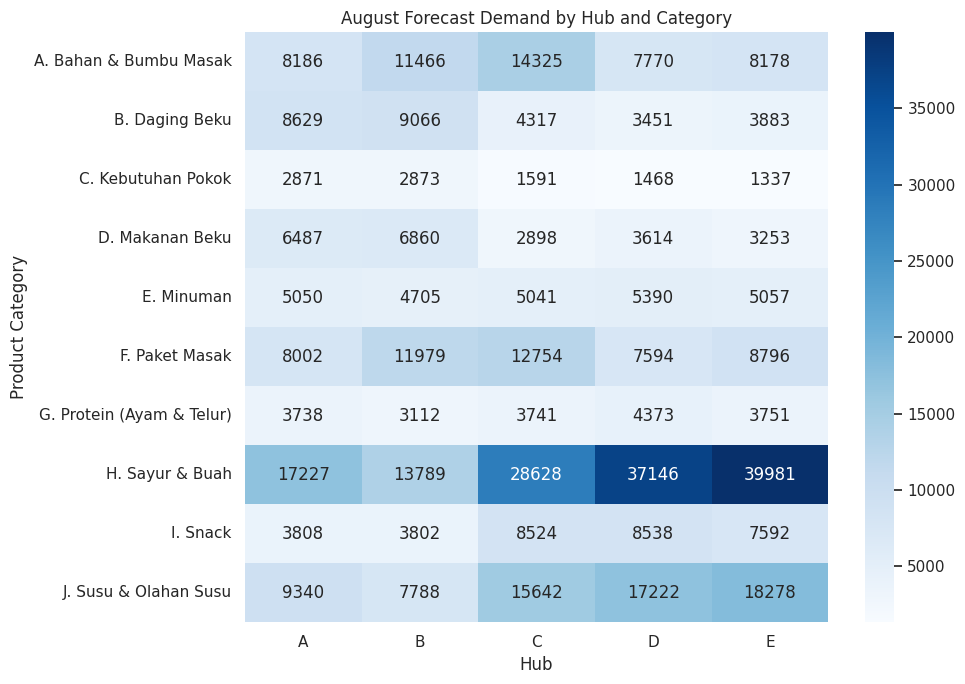

In [ ]:
# Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='Blues'
)

plt.title('August Forecast Demand by Hub and Category')
plt.xlabel('Hub')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

In [ ]:
# Download file demand
df_demand.to_csv('quicku_historical.csv', index=False)

In [ ]:
from google.colab import files
files.download('quicku_historical.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Download file forecasting
hub_category_forecast.to_csv(
    'quicku_forecast_hub_category.csv',
    index=False
)

In [ ]:
from google.colab import files

files.download('quicku_forecast_hub_category.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>